---
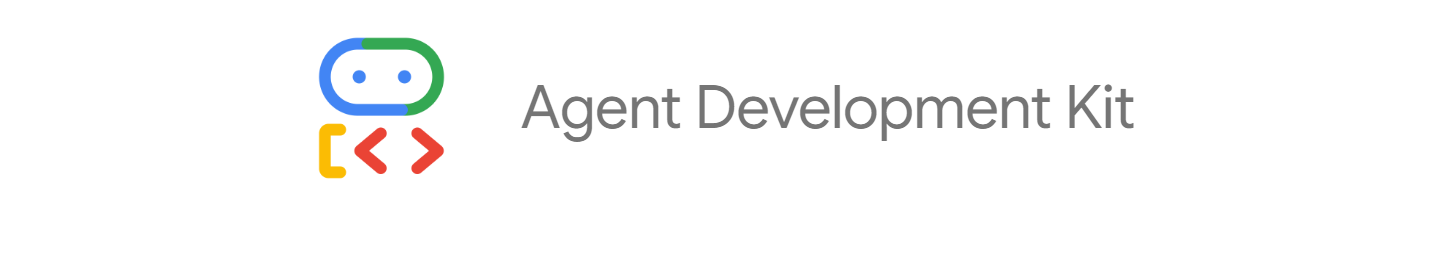

---

# Context in ADK

---


## What are Context
In the **Agent Development Kit (ADK)**, "`context`" refers to the crucial bundle of information available to your agent and its tools during specific operations. Think of it as the necessary background knowledge and resources needed to handle a current task or conversation turn effectively.

Agents often need more than just the latest user message to perform well. Context is essential because it enables:
1. **Maintaining State:** Remembering details across multiple steps in a conversation (e.g., user preferences, previous calculations, items in a shopping cart). This is primarily managed through session state.
2. **Passing Data:** Sharing information discovered or generated in one step (like an LLM call or a tool execution) with subsequent steps. Session state is key here too.
3. **Accessing Services:** Interacting with framework capabilities like:
    - **Artifact Storage:** Saving or loading files or data blobs (like PDFs, images, configuration files) associated with the session.
    - **Memory:** Searching for relevant information from past interactions or external knowledge sources connected to the user.
    - **Authentication:** Requesting and retrieving credentials needed by tools to access external APIs securely.
4. **Identity and Tracking:** Knowing which agent is currently running (agent.name) and uniquely identifying the current request-response cycle (invocation_id) for logging and debugging.
5. **Tool-Specific Actions:** Enabling specialized operations within tools, such as requesting authentication or searching memory, which require access to the current interaction's details.

> The central piece holding all this information together for a single, complete user-request-to-final-response cycle (an **invocation**) is the InvocationContext. However, you typically won't create or manage this object directly. The ADK framework creates it when an invocation starts (e.g., via runner.run_async) and passes the relevant contextual information implicitly to your agent code, callbacks, and tools.

```Python
# Conceptual Pseudocode: How the framework provides context (Internal Logic)

# runner = Runner(agent=my_root_agent, session_service=..., artifact_service=...)
# user_message = types.Content(...)
# session = session_service.get_session(...) # Or create new

# --- Inside runner.run_async(...) ---
# 1. Framework creates the main context for this specific run
# invocation_context = InvocationContext(
#     invocation_id="unique-id-for-this-run",
#     session=session,
#     user_content=user_message,
#     agent=my_root_agent, # The starting agent
#     session_service=session_service,
#     artifact_service=artifact_service,
#     memory_service=memory_service,
#     # ... other necessary fields ...
# )
#
# 2. Framework calls the agent's run method, passing the context implicitly
#    (The agent's method signature will receive it, e.g., runAsyncImpl(InvocationContext invocationContext))
# await my_root_agent.run_async(invocation_context)
#   --- End Internal Logic ---
#
# As a developer, you work with the context objects provided in method arguments.
```
<br>

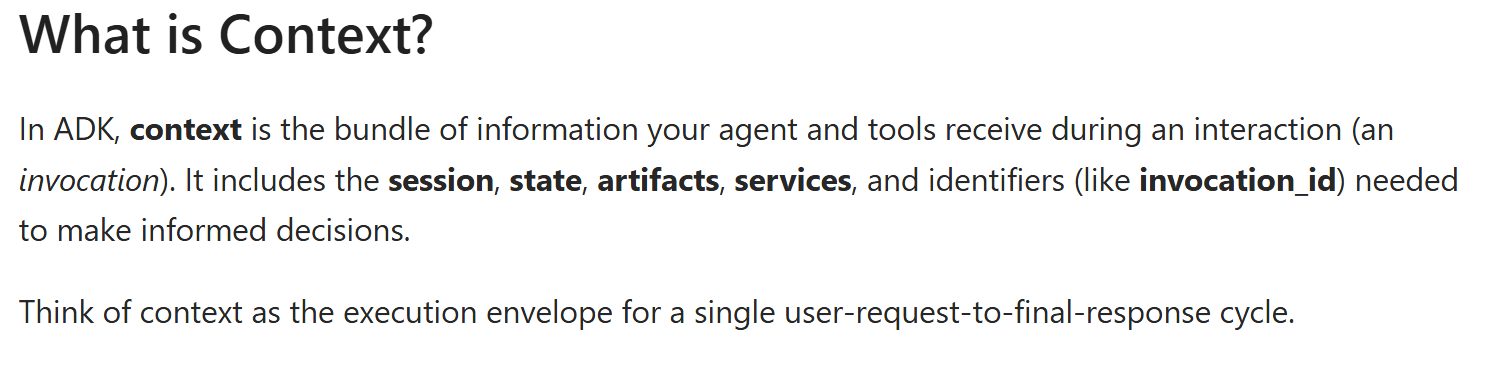 <br> 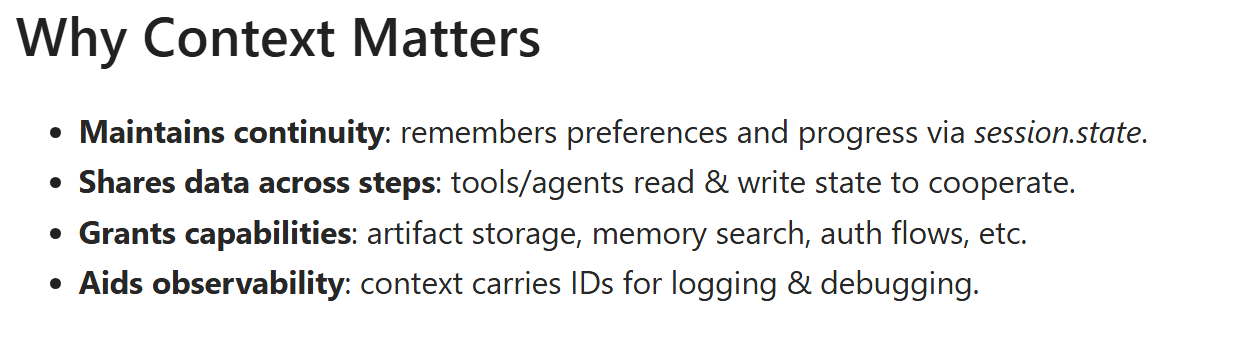 <br><br>

### `Context-Flow (High-Level Diagram)`
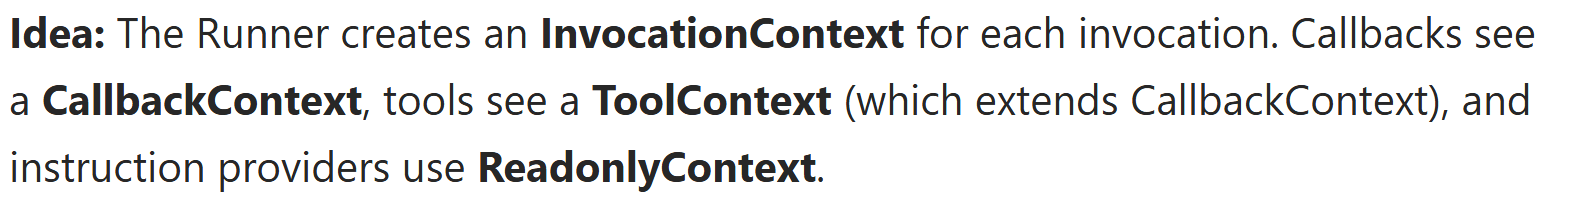

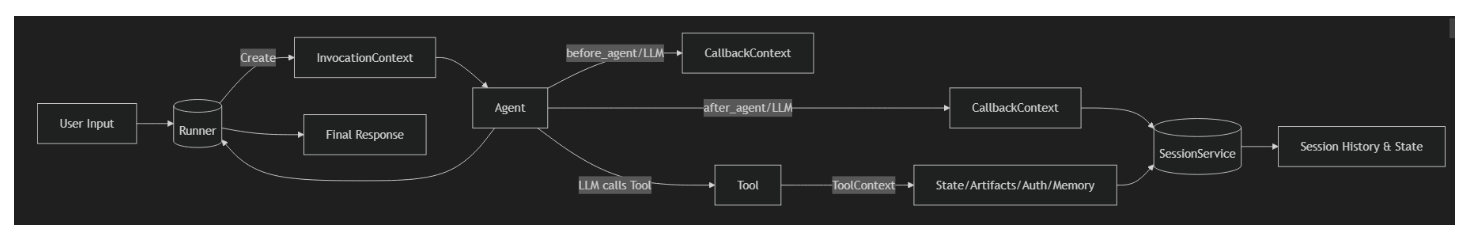

---


## The Different types of Context
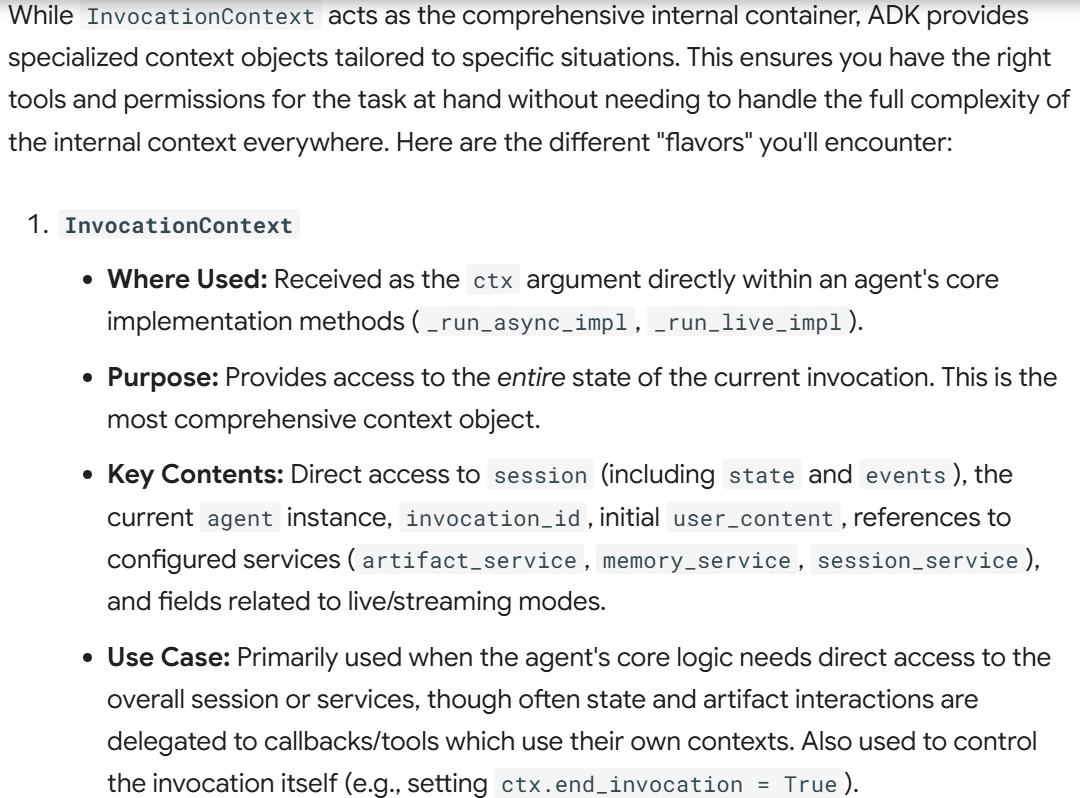

```Python
# Pseudocode: Agent implementation receiving InvocationContext
from google.adk.agents import BaseAgent
from google.adk.agents.invocation_context import InvocationContext
from google.adk.events import Event
from typing import AsyncGenerator

class MyAgent(BaseAgent):
    async def _run_async_impl(self, ctx: InvocationContext) -> AsyncGenerator[Event, None]:
        # Direct access example
        agent_name = ctx.agent.name
        session_id = ctx.session.id
        print(f"Agent {agent_name} running in session {session_id} for invocation {ctx.invocation_id}")
        # ... agent logic using ctx ...
        yield # ... event ...
```
<br>

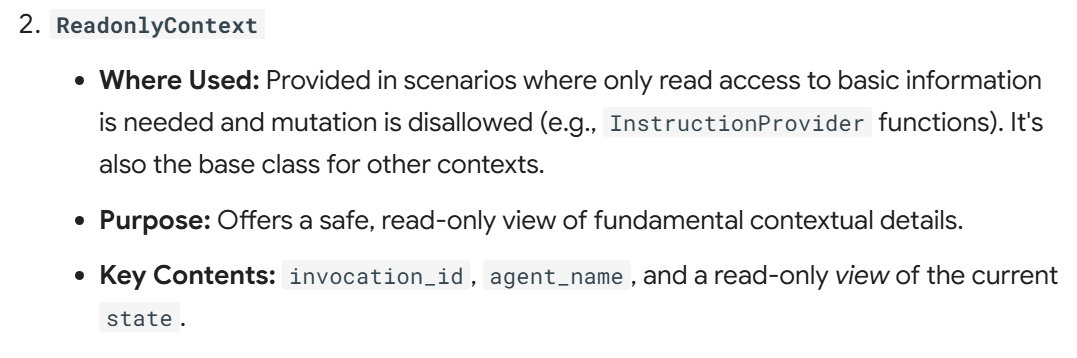

```Python
# Pseudocode: Instruction provider receiving ReadonlyContext
from google.adk.agents.readonly_context import ReadonlyContext

def my_instruction_provider(context: ReadonlyContext) -> str:
    # Read-only access example
    user_tier = context.state().get("user_tier", "standard") # Can read state
    # context.state['new_key'] = 'value' # This would typically cause an error or be ineffective
    return f"Process the request for a {user_tier} user."
```
<br>

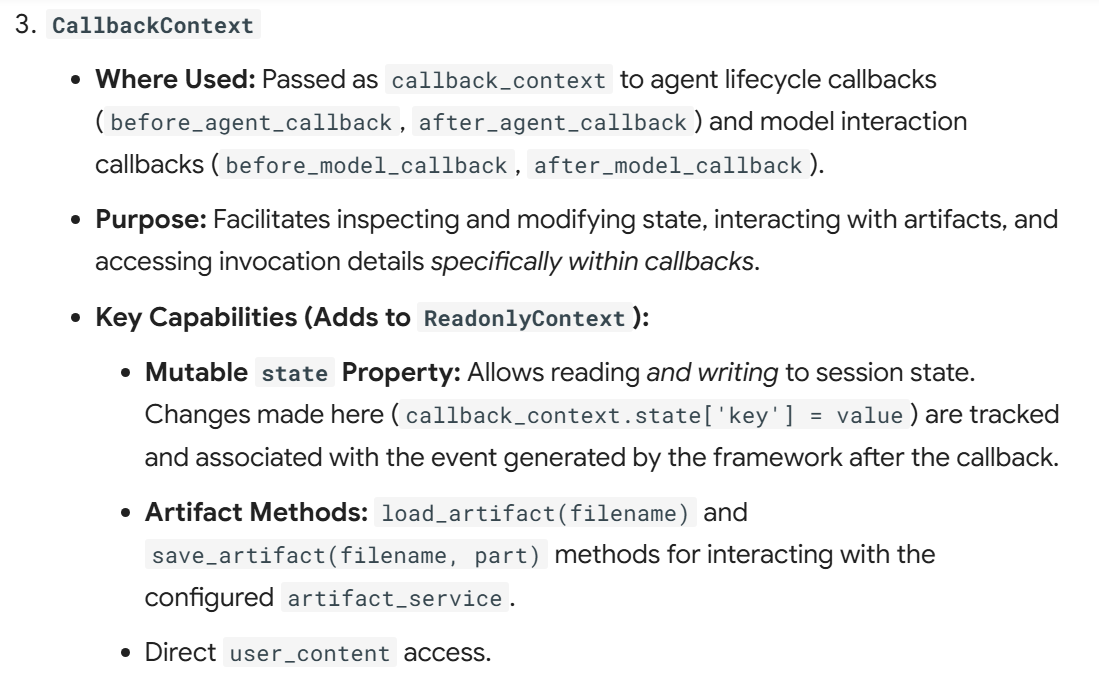

```Python
# Pseudocode: Callback receiving CallbackContext
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmRequest
from google.genai import types
from typing import Optional

def my_before_model_cb(callback_context: CallbackContext, request: LlmRequest) -> Optional[types.Content]:
    # Read/Write state example
    call_count = callback_context.state.get("model_calls", 0)
    callback_context.state["model_calls"] = call_count + 1 # Modify state

    # Optionally load an artifact
    # config_part = callback_context.load_artifact("model_config.json")
    print(f"Preparing model call #{call_count + 1} for invocation {callback_context.invocation_id}")
    return None # Allow model call to proceed
```
<br>

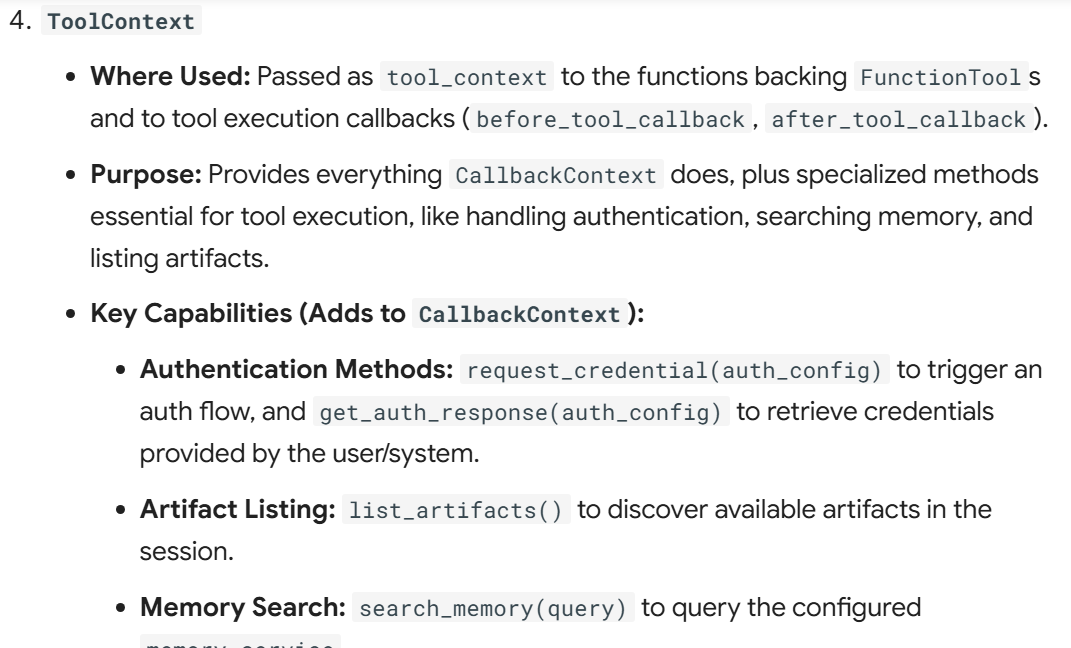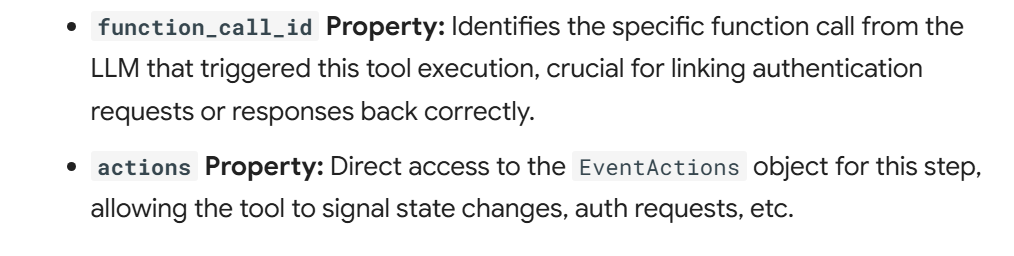

```Python
# Pseudocode: Tool function receiving ToolContext
from google.adk.tools import ToolContext
from typing import Dict, Any

# Assume this function is wrapped by a FunctionTool
def search_external_api(query: str, tool_context: ToolContext) -> Dict[str, Any]:
    api_key = tool_context.state.get("api_key")
    if not api_key:
        # Define required auth config
        # auth_config = AuthConfig(...)
        # tool_context.request_credential(auth_config) # Request credentials
        # Use the 'actions' property to signal the auth request has been made
        # tool_context.actions.requested_auth_configs[tool_context.function_call_id] = auth_config
        return {"status": "Auth Required"}

    # Use the API key...
    print(f"Tool executing for query '{query}' using API key. Invocation: {tool_context.invocation_id}")

    # Optionally search memory or list artifacts
    # relevant_docs = tool_context.search_memory(f"info related to {query}")
    # available_files = tool_context.list_artifacts()

    return {"result": f"Data for {query} fetched."}
```
<br>

> Understanding these different context objects and when to use them is key to effectively managing state, accessing services, and controlling the flow of your ADK application. The next section will detail common tasks you can perform using these contexts.

----
### `Types of Context`
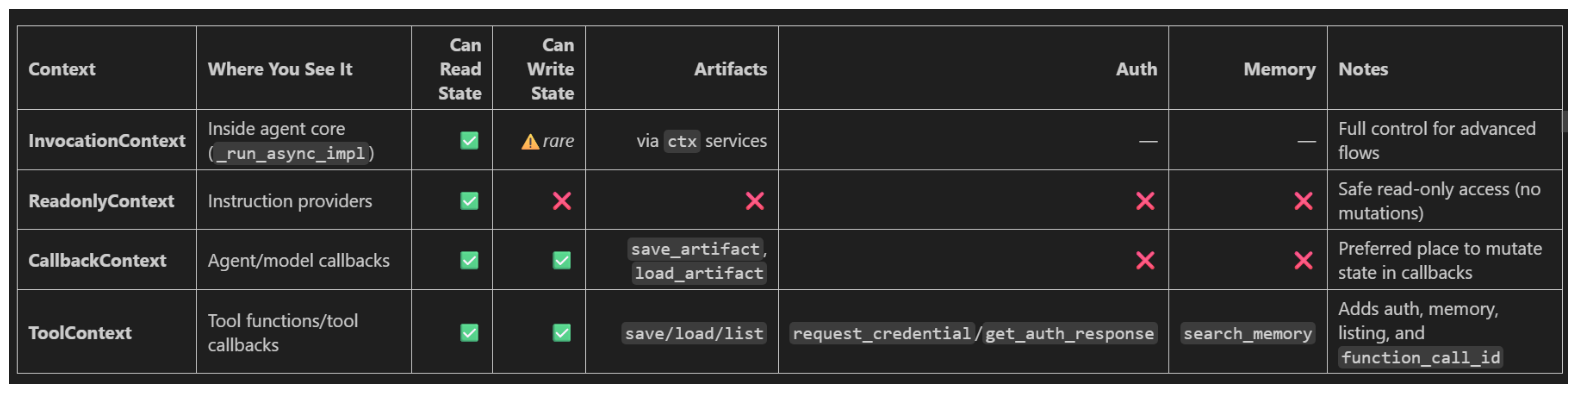

----

## Common Tasks Using Context
Now that you understand the different context objects, let's focus on how to use them for common tasks when building your agents and tools.

### Accessing Information
- **Reading Session State:** Access data saved in previous steps or user/app-level settings. Use dictionary-like access on the state property.

```Python
# Pseudocode: In a Tool function
from google.adk.tools import ToolContext

def my_tool(tool_context: ToolContext, **kwargs):
    user_pref = tool_context.state.get("user_display_preference", "default_mode")
    api_endpoint = tool_context.state.get("app:api_endpoint") # Read app-level state

    if user_pref == "dark_mode":
        # ... apply dark mode logic ...
        pass
    print(f"Using API endpoint: {api_endpoint}")
    # ... rest of tool logic ...

# Pseudocode: In a Callback function
from google.adk.agents.callback_context import CallbackContext

def my_callback(callback_context: CallbackContext, **kwargs):
    last_tool_result = callback_context.state.get("temp:last_api_result") # Read temporary state
    if last_tool_result:
        print(f"Found temporary result from last tool: {last_tool_result}")
    # ... callback logic ...
```

- **Getting Current Identifiers:** Useful for logging or custom logic based on the current operation.

```Python
# Pseudocode: In any context (ToolContext shown)
from google.adk.tools import ToolContext

def log_tool_usage(tool_context: ToolContext, **kwargs):
    agent_name = tool_context.agent_nameSystem.out.println("Found temporary result from last tool: " + lastToolResult);
    inv_id = tool_context.invocation_id
    func_call_id = getattr(tool_context, 'function_call_id', 'N/A') # Specific to ToolContext

    print(f"Log: Invocation={inv_id}, Agent={agent_name}, FunctionCallID={func_call_id} - Tool Executed.")
```

- **Accessing the Initial User Input:** Refer back to the message that started the current invocation.

```Python
# Pseudocode: In a Callback
from google.adk.agents.callback_context import CallbackContext

def check_initial_intent(callback_context: CallbackContext, **kwargs):
    initial_text = "N/A"
    if callback_context.user_content and callback_context.user_content.parts:
        initial_text = callback_context.user_content.parts[0].text or "Non-text input"

    print(f"This invocation started with user input: '{initial_text}'")

# Pseudocode: In an Agent's _run_async_impl
# async def _run_async_impl(self, ctx: InvocationContext) -> AsyncGenerator[Event, None]:
#     if ctx.user_content and ctx.user_content.parts:
#         initial_text = ctx.user_content.parts[0].text
#         print(f"Agent logic remembering initial query: {initial_text}")
#     ...
```

----

## Managing State
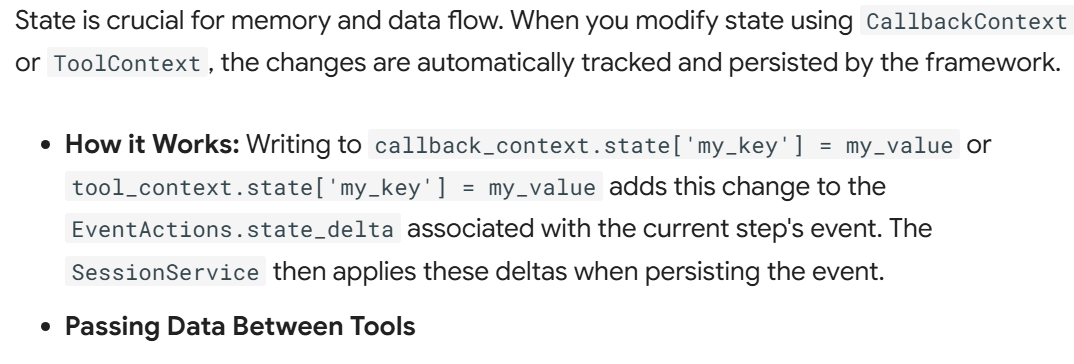

```Python
# Pseudocode: Tool 1 - Fetches user ID
from google.adk.tools import ToolContext
import uuid

def get_user_profile(tool_context: ToolContext) -> dict:
    user_id = str(uuid.uuid4()) # Simulate fetching ID
    # Save the ID to state for the next tool
    tool_context.state["temp:current_user_id"] = user_id
    return {"profile_status": "ID generated"}

# Pseudocode: Tool 2 - Uses user ID from state
def get_user_orders(tool_context: ToolContext) -> dict:
    user_id = tool_context.state.get("temp:current_user_id")
    if not user_id:
        return {"error": "User ID not found in state"}

    print(f"Fetching orders for user ID: {user_id}")
    # ... logic to fetch orders using user_id ...
    return {"orders": ["order123", "order456"]}
```
- **Updating User Preferences:**

```Python
# Pseudocode: Tool or Callback identifies a preference
from google.adk.tools import ToolContext # Or CallbackContext

def set_user_preference(tool_context: ToolContext, preference: str, value: str) -> dict:
    # Use 'user:' prefix for user-level state (if using a persistent SessionService)
    state_key = f"user:{preference}"
    tool_context.state[state_key] = value
    print(f"Set user preference '{preference}' to '{value}'")
    return {"status": "Preference updated"}
```

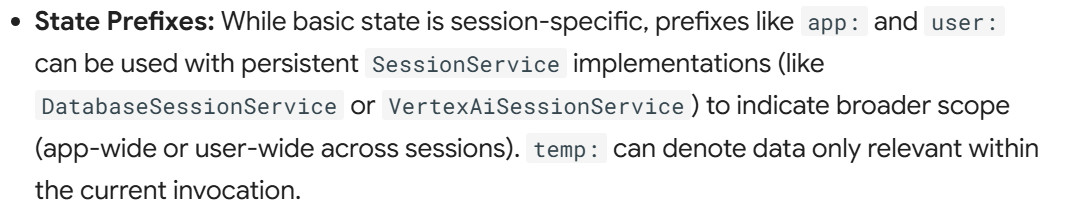

----


## Working with Artifacts
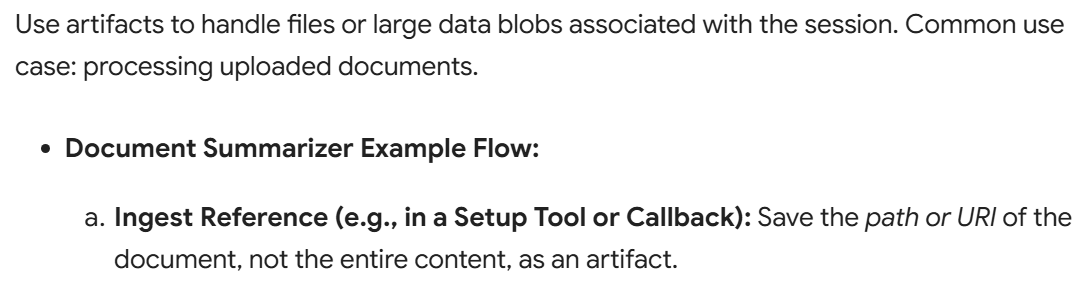

```Python
# Pseudocode: In a callback or initial tool
from google.adk.agents.callback_context import CallbackContext # Or ToolContext
from google.genai import types

def save_document_reference(context: CallbackContext, file_path: str) -> None:
    # Assume file_path is something like "gs://my-bucket/docs/report.pdf" or "/local/path/to/report.pdf"
    try:
        # Create a Part containing the path/URI text
        artifact_part = types.Part(text=file_path)
        version = context.save_artifact("document_to_summarize.txt", artifact_part)
        print(f"Saved document reference '{file_path}' as artifact version {version}")
        # Store the filename in state if needed by other tools
        context.state["temp:doc_artifact_name"] = "document_to_summarize.txt"
    except ValueError as e:
        print(f"Error saving artifact: {e}") # E.g., Artifact service not configured
    except Exception as e:
        print(f"Unexpected error saving artifact reference: {e}")

# Example usage:
# save_document_reference(callback_context, "gs://my-bucket/docs/report.pdf")
```

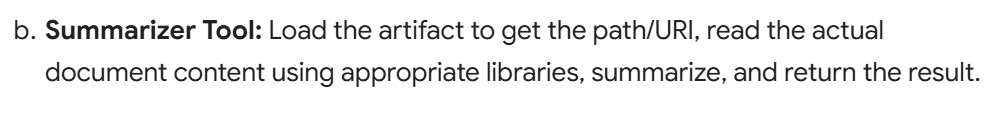

```Python
# Pseudocode: In the Summarizer tool function
from google.adk.tools import ToolContext
from google.genai import types
# Assume libraries like google.cloud.storage or built-in open are available
# Assume a 'summarize_text' function exists
# from my_summarizer_lib import summarize_text

def summarize_document_tool(tool_context: ToolContext) -> dict:
    artifact_name = tool_context.state.get("temp:doc_artifact_name")
    if not artifact_name:
        return {"error": "Document artifact name not found in state."}

    try:
        # 1. Load the artifact part containing the path/URI
        artifact_part = tool_context.load_artifact(artifact_name)
        if not artifact_part or not artifact_part.text:
            return {"error": f"Could not load artifact or artifact has no text path: {artifact_name}"}

        file_path = artifact_part.text
        print(f"Loaded document reference: {file_path}")

        # 2. Read the actual document content (outside ADK context)
        document_content = ""
        if file_path.startswith("gs://"):
            # Example: Use GCS client library to download/read
            # from google.cloud import storage
            # client = storage.Client()
            # blob = storage.Blob.from_string(file_path, client=client)
            # document_content = blob.download_as_text() # Or bytes depending on format
            pass # Replace with actual GCS reading logic
        elif file_path.startswith("/"):
             # Example: Use local file system
             with open(file_path, 'r', encoding='utf-8') as f:
                 document_content = f.read()
        else:
            return {"error": f"Unsupported file path scheme: {file_path}"}

        # 3. Summarize the content
        if not document_content:
             return {"error": "Failed to read document content."}

        # summary = summarize_text(document_content) # Call your summarization logic
        summary = f"Summary of content from {file_path}" # Placeholder

        return {"summary": summary}

    except ValueError as e:
         return {"error": f"Artifact service error: {e}"}
    except FileNotFoundError:
         return {"error": f"Local file not found: {file_path}"}
    # except Exception as e: # Catch specific exceptions for GCS etc.
    #      return {"error": f"Error reading document {file_path}: {e}"}
```

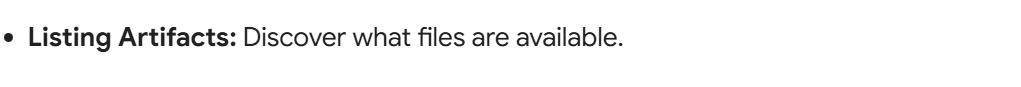

```Python
# Pseudocode: In a tool function
from google.adk.tools import ToolContext

def check_available_docs(tool_context: ToolContext) -> dict:
    try:
        artifact_keys = tool_context.list_artifacts()
        print(f"Available artifacts: {artifact_keys}")
        return {"available_docs": artifact_keys}
    except ValueError as e:
        return {"error": f"Artifact service error: {e}"}

```

----

## Handling Tool Authentication
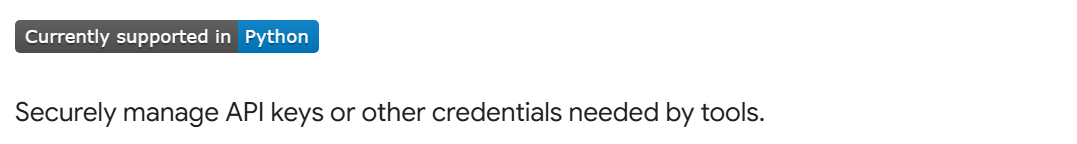 

```Python
# Pseudocode: Tool requiring auth
from google.adk.tools import ToolContext
from google.adk.auth import AuthConfig # Assume appropriate AuthConfig is defined

# Define your required auth configuration (e.g., OAuth, API Key)
MY_API_AUTH_CONFIG = AuthConfig(...)
AUTH_STATE_KEY = "user:my_api_credential" # Key to store retrieved credential

def call_secure_api(tool_context: ToolContext, request_data: str) -> dict:
    # 1. Check if credential already exists in state
    credential = tool_context.state.get(AUTH_STATE_KEY)

    if not credential:
        # 2. If not, request it
        print("Credential not found, requesting...")
        try:
            tool_context.request_credential(MY_API_AUTH_CONFIG)
            # The framework handles yielding the event. The tool execution stops here for this turn.
            return {"status": "Authentication required. Please provide credentials."}
        except ValueError as e:
            return {"error": f"Auth error: {e}"} # e.g., function_call_id missing
        except Exception as e:
            return {"error": f"Failed to request credential: {e}"}

    # 3. If credential exists (might be from a previous turn after request)
    #    or if this is a subsequent call after auth flow completed externally
    try:
        # Optionally, re-validate/retrieve if needed, or use directly
        # This might retrieve the credential if the external flow just completed
        auth_credential_obj = tool_context.get_auth_response(MY_API_AUTH_CONFIG)
        api_key = auth_credential_obj.api_key # Or access_token, etc.

        # Store it back in state for future calls within the session
        tool_context.state[AUTH_STATE_KEY] = auth_credential_obj.model_dump() # Persist retrieved credential

        print(f"Using retrieved credential to call API with data: {request_data}")
        # ... Make the actual API call using api_key ...
        api_result = f"API result for {request_data}"

        return {"result": api_result}
    except Exception as e:
        # Handle errors retrieving/using the credential
        print(f"Error using credential: {e}")
        # Maybe clear the state key if credential is invalid?
        # tool_context.state[AUTH_STATE_KEY] = None
        return {"error": "Failed to use credential"}
```
> **Remember:** request_credential pauses the tool and signals the need for authentication. The user/system provides credentials, and on a subsequent call, get_auth_response (or checking state again) allows the tool to proceed. The tool_context.function_call_id is used implicitly by the framework to link the request and response.

---

## Leveraging Memory
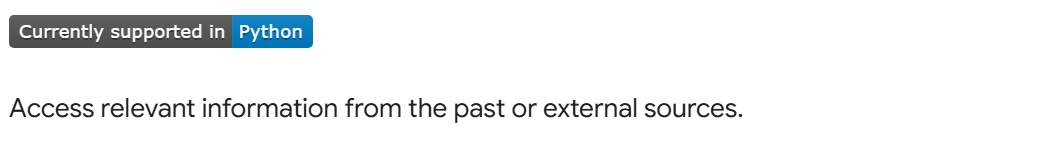

```Python
# Pseudocode: Tool using memory search
from google.adk.tools import ToolContext

def find_related_info(tool_context: ToolContext, topic: str) -> dict:
    try:
        search_results = tool_context.search_memory(f"Information about {topic}")
        if search_results.results:
            print(f"Found {len(search_results.results)} memory results for '{topic}'")
            # Process search_results.results (which are SearchMemoryResponseEntry)
            top_result_text = search_results.results[0].text
            return {"memory_snippet": top_result_text}
        else:
            return {"message": "No relevant memories found."}
    except ValueError as e:
        return {"error": f"Memory service error: {e}"} # e.g., Service not configured
    except Exception as e:
        return {"error": f"Unexpected error searching memory: {e}"}
```
---

## **Advanced:** Direct ``InvocationContext`` Usage
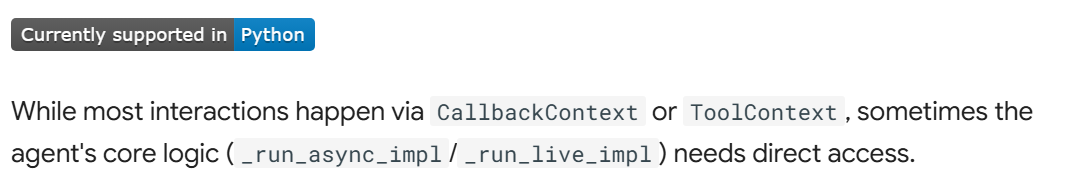

```Python
# Pseudocode: Inside agent's _run_async_impl
from google.adk.agents import BaseAgent
from google.adk.agents.invocation_context import InvocationContext
from google.adk.events import Event
from typing import AsyncGenerator

class MyControllingAgent(BaseAgent):
    async def _run_async_impl(self, ctx: InvocationContext) -> AsyncGenerator[Event, None]:
        # Example: Check if a specific service is available
        if not ctx.memory_service:
            print("Memory service is not available for this invocation.")
            # Potentially change agent behavior

        # Example: Early termination based on some condition
        if ctx.session.state.get("critical_error_flag"):
            print("Critical error detected, ending invocation.")
            ctx.end_invocation = True # Signal framework to stop processing
            yield Event(author=self.name, invocation_id=ctx.invocation_id, content="Stopping due to critical error.")
            return # Stop this agent's execution

        # ... Normal agent processing ...
        yield # ... event ...
```

> Setting ctx.end_invocation = True is a way to gracefully stop the entire request-response cycle from within the agent or its callbacks/tools (via their respective context objects which also have access to modify the underlying InvocationContext's flag).

---

## Key Takeaways & Best Practices
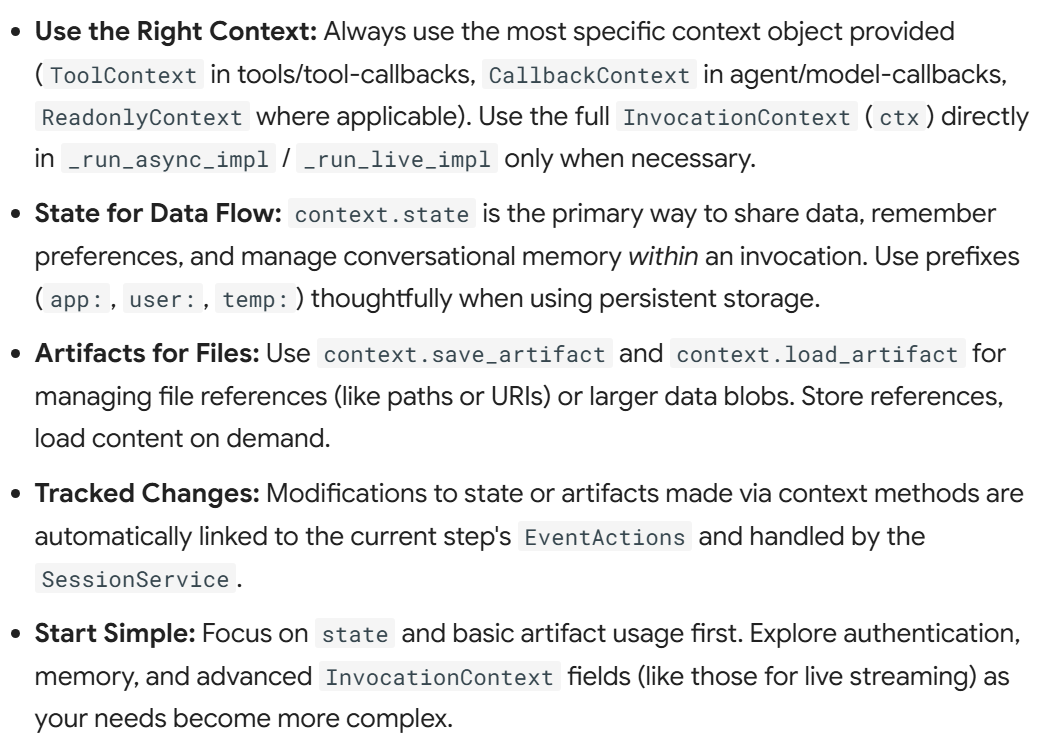

> By understanding and effectively using these context objects, you can build more sophisticated, stateful, and capable agents with **ADK**.

---